In [1]:
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import torch

import sde_lib
import dnnlib
import solver_lib

torch.manual_seed(0)

In [2]:
with dnnlib.util.open_url("../model/edm2-img64-xl-0671088-0.040.pkl") as f:
    data = pickle.load(f)
model = data["ema"].to("cuda")

In [3]:
encoder = data.get('encoder', None)
if encoder is None:
    encoder = dnnlib.util.construct_class_by_name(class_name='training.encoders.StandardRGBEncoder')

In [4]:
x = torch.zeros((16, model.img_channels, model.img_resolution, model.img_resolution)).to("cuda")
t = torch.ones((1,)).to("cuda")
noise = torch.randn_like(x) * 80

In [5]:
labels = torch.eye(model.label_dim, device="cuda")[torch.randint(high=model.label_dim, size=(16,), device="cuda")]

In [6]:
sigma_min = 0.002
sigma_max = 80

sde_ = sde_lib.EDMSDE().to("cuda")
rsde = sde_.get_reverse_sde(model, ode_threshold=0.2).to("cuda")
rsde.ode = False

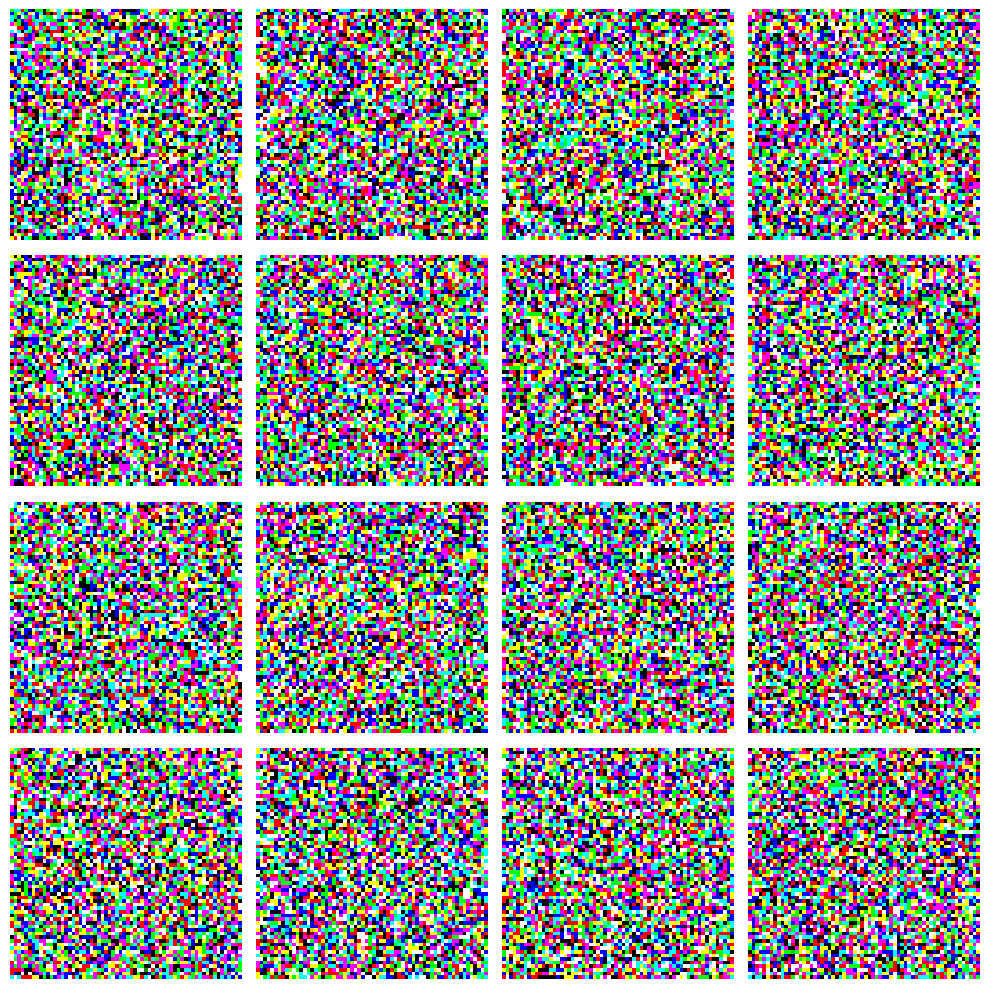

In [7]:
images = encoder.decode(noise).permute(0, 2, 3, 1)

def plot_images(images):
    fig, axes = plt.subplots(4, 4)
    fig.set_size_inches(10, 10)
    
    for i in range(4):
        for j in range(4):
            axes[i][j].imshow(images[i * 4 + j])
            axes[i][j].axis("off")
            
    fig.tight_layout()
    
plot_images(images.cpu())

In [9]:
n_steps = 70
rho = 7
# From EDM2 code
step_indices = torch.arange(n_steps)
sigma_steps = (sigma_max ** (1 / rho) + step_indices / (n_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
discretisation = torch.cat([sigma_steps, torch.zeros_like(sigma_steps[:1])])

In [10]:
rsde.reset()

em_solver = solver_lib.EulerMarayumaSolver(rsde, discretisation).to("cuda")

x_em = em_solver.solve(noise.clone(), labels)

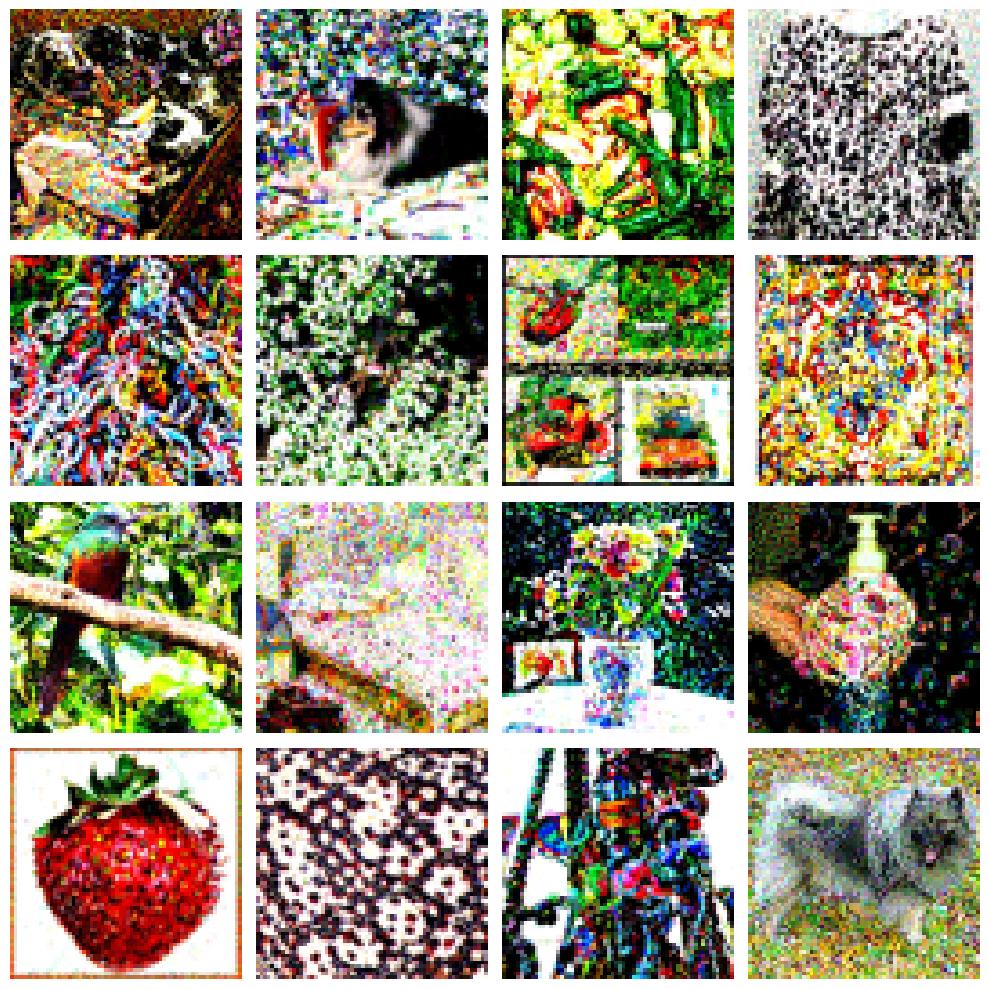

In [11]:
images = encoder.decode(x_em).permute(0, 2, 3, 1)

plot_images(images.cpu())

In [8]:
sigmas = []
sigmas_std = []
def pi_callback(x, t, h, error):    
    print(f"sigma = {torch.mean(t)}", end=" ")
    print(f"h = {torch.mean(h)}", end=" ")
    print(f"error = {torch.mean(error)}")
    sigmas.append(torch.mean(t).cpu())
    sigmas_std.append(torch.std(t).cpu())

In [10]:
sigmas = []
sigmas_std = []

rsde.reset()

pi_solver = solver_lib.PISolver(
    rsde,
    ki=0.3,
    kp=0.01, 
    tau_a=1,
    tau_r=10,
    alpha=0.9,
    h_start=0.5,
    max_decrease=0.05,
    max_increase=10,
    interval=(80, 0),
    abs_error=False
).to("cuda")

x_pi = pi_solver.solve(noise.clone(), labels, callback=pi_callback)

sigma = 79.5 h = -4.297839164733887 error = 0.0008554833475500345
sigma = 75.20216369628906 h = -12.327095031738281 error = 0.024021849036216736
sigma = 62.87506866455078 h = -20.16867446899414 error = 0.16359353065490723
sigma = 42.70639419555664 h = -21.047088623046875 error = 0.7424309849739075
sigma = 42.70639419555664 h = -15.335203170776367 error = 2.483832359313965
sigma = 42.70639419555664 h = -14.616667747497559 error = 1.0858373641967773
sigma = 28.089723587036133 h = -14.454887390136719 error = 0.9386007189750671
sigma = 28.089723587036133 h = -10.384435653686523 error = 2.619234085083008
sigma = 28.089723587036133 h = -9.506903648376465 error = 1.2385873794555664
sigma = 18.582820892333984 h = -9.393444061279297 error = 0.9452766180038452
sigma = 18.582820892333984 h = -6.665796279907227 error = 2.7259323596954346


KeyboardInterrupt: 

In [24]:
rsde.nfe / 16

192.0

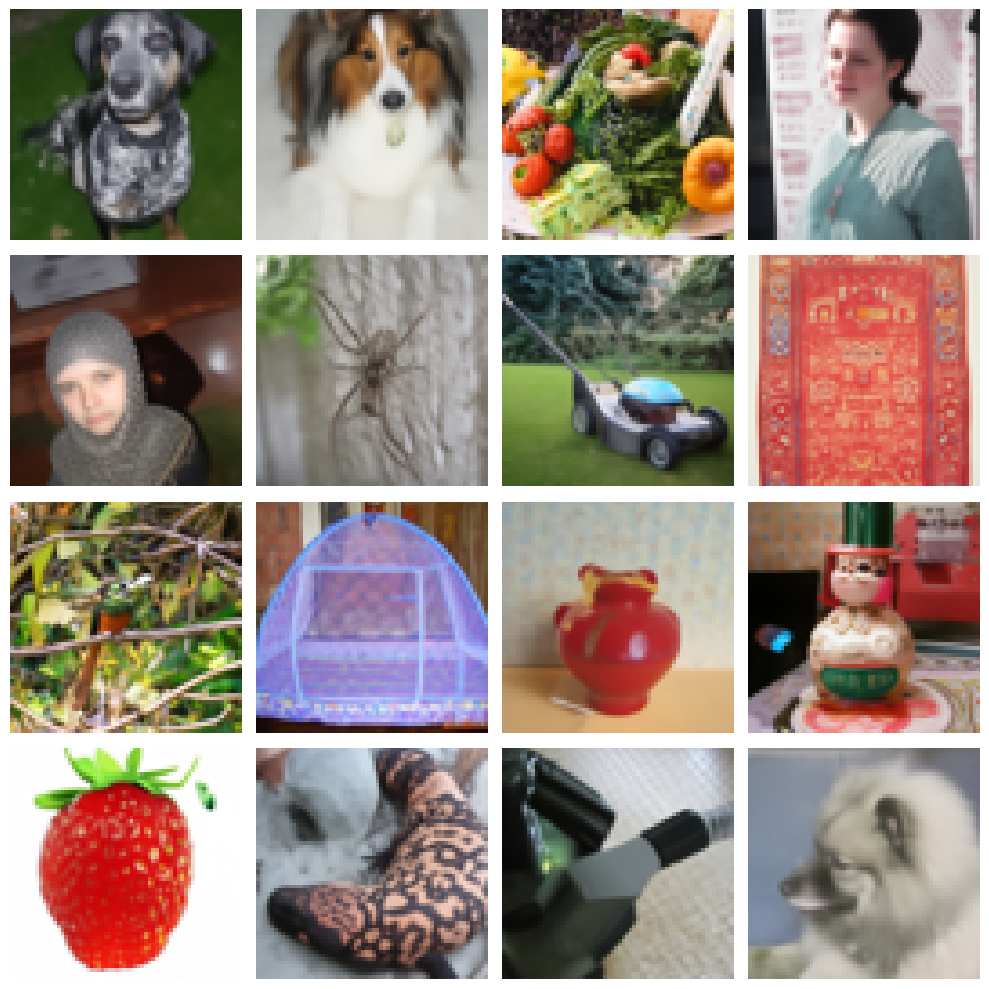

In [25]:
images = encoder.decode(x_pi).permute(0, 2, 3, 1)
plot_images(images.cpu())

Text(0, 0.5, 'sigma')

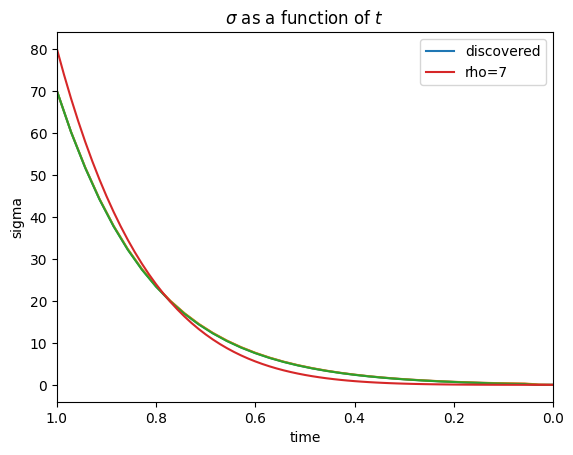

In [16]:
plt.title(r"$\sigma$ as a function of $t$")
plt.plot(torch.linspace(1, 0, len(sigmas)), sigmas, label="discovered")
plt.plot(torch.linspace(1, 0, len(sigmas)), torch.tensor(sigmas) + torch.tensor(sigmas_std))
plt.plot(torch.linspace(1, 0, len(sigmas)), torch.tensor(sigmas) - torch.tensor(sigmas_std))
plt.plot(torch.linspace(1, 0, len(discretisation)), discretisation.cpu(), label="rho=7")
plt.legend()
plt.xlim(1, 0)
plt.xlabel("time")
plt.ylabel("sigma")

In [17]:
x_edm = solver_lib.edm_sampler(model, noise.clone() / 80, labels, num_steps=n_steps // 2)

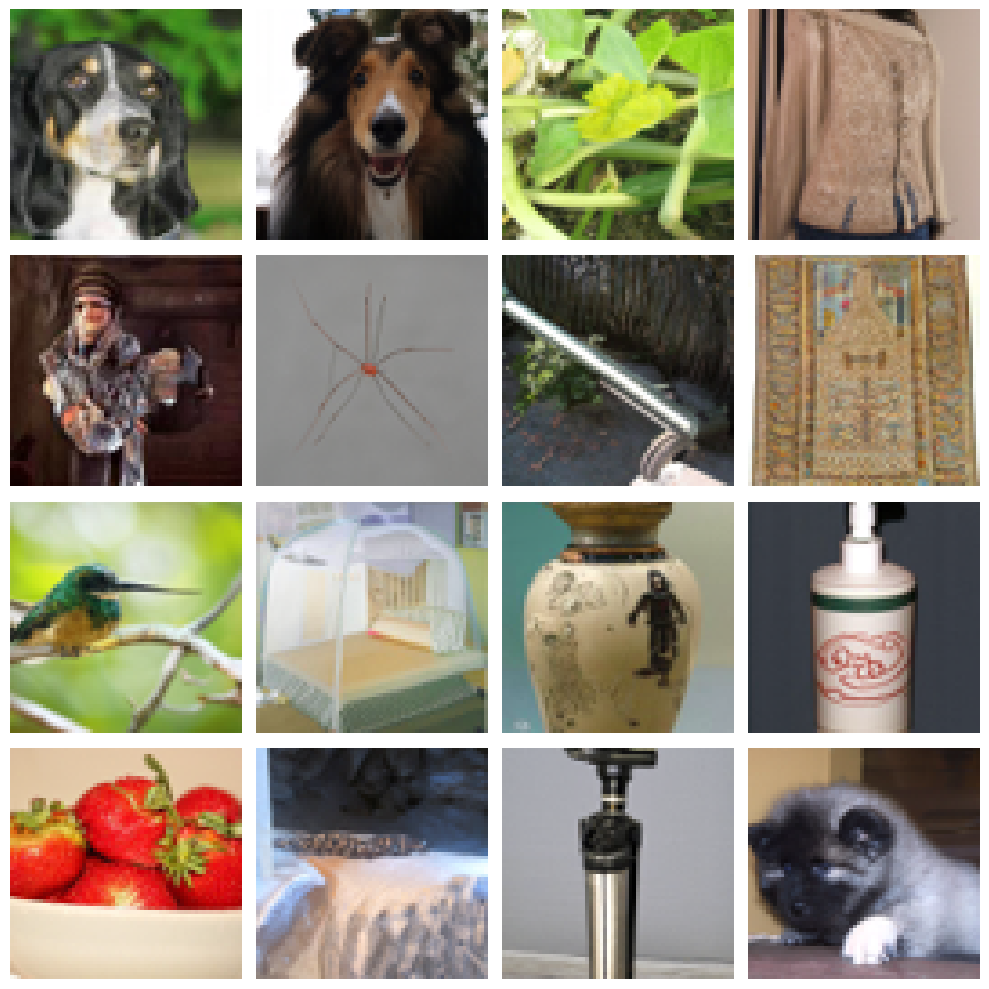

In [18]:
images = encoder.decode(x_edm).permute(0, 2, 3, 1)
plot_images(images.cpu())

In [19]:
df_h = pd.read_csv("../data/image_testing/pi/test/data/_h.csv")
df_t = pd.read_csv("../data/image_testing/pi/test/data/_t.csv")

In [20]:
df_t

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,140,141,142,143,144,145,146,147,148,149
0,0,77.0,72.74491,67.768660,62.054424,55.861683,49.485405,43.182796,37.184338,31.676067,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,77.0,72.74490,67.745865,62.018020,55.833840,49.474262,43.169678,37.188450,31.676083,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,77.0,72.74393,67.750435,62.020240,55.829140,49.448060,43.152298,37.166004,31.614014,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,77.0,72.74429,67.738700,62.009632,55.833923,49.469486,43.185944,37.189423,31.675102,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,77.0,72.74434,67.747550,62.042610,55.854210,49.475790,43.170160,37.168568,31.633130,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,35,77.0,72.74552,67.737114,61.990180,55.817383,49.451588,43.128075,37.104640,31.582340,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
996,36,77.0,72.74550,67.770230,62.064827,55.868958,49.471626,43.213493,37.205276,31.691120,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
997,37,77.0,72.74565,67.752625,62.052254,55.878387,49.528960,43.253773,37.268887,31.753305,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
998,38,77.0,72.74628,67.752235,62.031240,55.835210,49.443752,43.102055,37.104603,31.583014,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
